<a href="https://colab.research.google.com/github/mtchlorence/Projects/blob/main/Cost_of_Living_Index_by_Country.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [6]:
# IMPORTANT: RUN THIS CELL IN ORDER TO IMPORT YOUR KAGGLE DATA SOURCES,
# THEN FEEL FREE TO DELETE THIS CELL.
# NOTE: THIS NOTEBOOK ENVIRONMENT DIFFERS FROM KAGGLE'S PYTHON
# ENVIRONMENT SO THERE MAY BE MISSING LIBRARIES USED BY YOUR
# NOTEBOOK.
import kagglehub
myrios_cost_of_living_index_by_country_by_number_2024_path = kagglehub.dataset_download('myrios/cost-of-living-index-by-country-by-number-2024')

print('Data source import complete.')


Using Colab cache for faster access to the 'cost-of-living-index-by-country-by-number-2024' dataset.
Data source import complete.


*This is my first Kaggle Notebook and my first practice in data analysis / data visualization using Python here.*

## Import Necessary Packages

In [7]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import plotly.express as px

## Load Dataset

In [16]:
data = pd.read_csv('/kaggle/input/cost-of-living-index-by-country-by-number-2024/Cost_of_Living_Index_by_Country_2024.csv')
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 121 entries, 0 to 120
Data columns (total 8 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Rank                            121 non-null    int64  
 1   Country                         121 non-null    object 
 2   Cost of Living Index            121 non-null    float64
 3   Rent Index                      121 non-null    float64
 4   Cost of Living Plus Rent Index  121 non-null    float64
 5   Groceries Index                 121 non-null    float64
 6   Restaurant Price Index          121 non-null    float64
 7   Local Purchasing Power Index    121 non-null    float64
dtypes: float64(6), int64(1), object(1)
memory usage: 7.7+ KB


In [9]:
data.describe()

,Rank,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
count,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000,121.000000
mean,61.000000,43.555372,16.052893,30.357851,44.228926,36.471074,65.094215
std,35.073732,16.147574,11.412267,13.263721,17.055109,18.258110,39.569094
min,1.000000,18.800000,2.400000,11.100000,17.500000,12.800000,2.300000
25%,31.000000,30.200000,8.500000,19.800000,31.600000,21.600000,34.800000
50%,61.000000,39.500000,12.400000,27.000000,40.500000,33.100000,50.600000
75%,91.000000,52.800000,20.100000,37.000000,53.700000,47.200000,99.400000
max,121.000000,101.100000,67.200000,74.900000,109.100000,97.000000,182.500000


In [10]:
data.head(10)

,Rank,Country,Cost of Living Index,Rent Index,Cost of Living Plus Rent Index,Groceries Index,Restaurant Price Index,Local Purchasing Power Index
0,1,Switzerland,101.1,46.5,74.9,109.1,97.0,158.7
1,2,Bahamas,85.0,36.7,61.8,81.6,83.3,54.6
2,3,Iceland,83.0,39.2,62.0,88.4,86.8,120.3
3,4,Singapore,76.7,67.2,72.1,74.6,50.4,111.1
4,5,Barbados,76.6,19.0,48.9,80.8,69.4,43.5
5,6,Norway,76.0,26.2,52.1,79.0,73.5,114.7
6,7,Denmark,72.3,26.4,50.2,64.8,81.3,127.2
7,8,Hong Kong (China),70.8,59.4,65.3,84.6,46.2,109.3
8,9,United States,70.4,41.7,56.6,75.0,67.2,142.3
9,10,Australia,70.2,33.4,52.5,77.3,62.5,127.4


## Manipulate the Data

### Cost of Living Index by Rent Index

In [11]:
fig = px.line(data, x="Cost of Living Index", y="Rent Index", title="Cost of Living Index by Rent Index")
fig.show()

### Cost of Living Plus Rent Index by Grocery Index

In [12]:
fig = px.scatter(data, x="Cost of Living Plus Rent Index", y="Groceries Index", color = 'Country', title="Cost of Living Plus Rent Index by Groceries Index")
fig.show()

### Top 5 Countries with the Lowest Cost of Living

In [14]:
# Sort the DataFrame by the "Cost of Living Index" in Descending order
df_sorted = data.sort_values(by="Cost of Living Index", ascending=False)

# Select the top 5 countries with the lowest "Cost of Living Index"
df_top5 = df_sorted.tail(5)

# Create the funnel plot
fig = px.funnel(df_top5, x='Cost of Living Index', y='Country', color_discrete_sequence=px.colors.sequential.Cividis)
fig.show()

### Correlation Matrix of Numeric Features

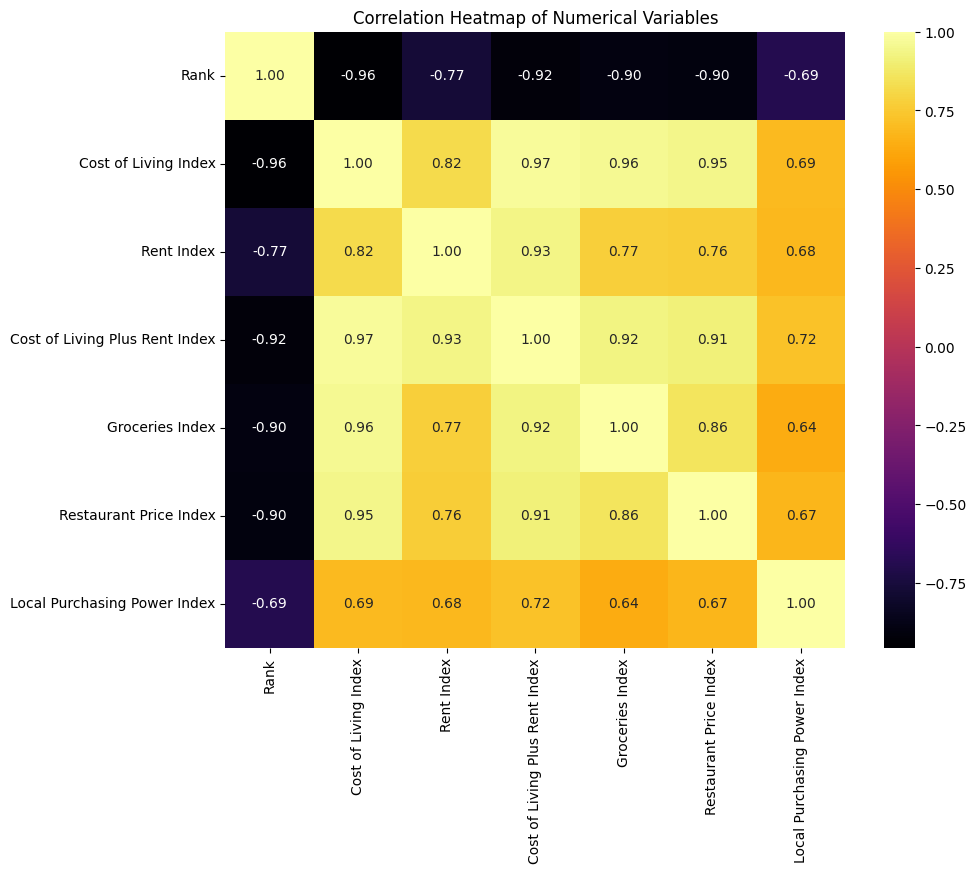

In [15]:
#Checking Correlation
dataCorr = data.drop(columns=['Country'])
dataCorr.corr()

# Calculate the correlation matrix
corr_matrix = dataCorr.corr()

# Plot the heatmap
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='inferno', fmt='.2f')
plt.title("Correlation Heatmap of Numerical Variables")
plt.show()
